# GDP–CO₂ Relationship Analysis: Time-series Extension

본 노트북은 1차 시각화 기반 탐색 분석을 확장하여,  
국가별 GDP와 CO₂ 배출량의 관계가 시간에 따라 어떻게 변화하는지를 시계열 관점에서 살펴본다.

## 주요 분석
1. 전 세계 GDP와 CO₂ 총량 추세
2. 대표 국가의 rolling correlation
3. 기간별 상관관계 변화 비교
4. Decoupling Index 분석

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform

sns.set_theme(style="whitegrid")
plt.rcParams["axes.unicode_minus"] = False

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

In [2]:
df = pd.read_csv("gdp_co2_by_country_v2.csv")
df = df.replace([np.inf, -np.inf], np.nan)

# 2차 분석에서도 동일한 핵심 컬럼 사용
cols = [
    "Country Name", "Country Code", "Year",
    "Population", "Pop Category",
    "CO2", "CO2 %", "Per Capita CO2 (kg)", "CO2 Log", "Emissions Category",
    "GDP USD", "GDP %", "GDP Per Capita", "GDP USD Log", "GDP Category"
]

df_ts = df[cols].copy()

print("데이터 크기:", df_ts.shape)
df_ts.head()

데이터 크기: (12444, 15)


,Country Name,Country Code,Year,Population,Pop Category,CO2,CO2 %,Per Capita CO2 (kg),CO2 Log,Emissions Category,GDP USD,GDP %,GDP Per Capita,GDP USD Log,GDP Category
0,Afghanistan,AFG,1961,9214082.0,1M-10M,0.491,NaN,0.000053,0.399447,Moderate,308.31827,-10.119484,0.000033,5.734371,Low GDP
1,Afghanistan,AFG,1962,9404411.0,1M-10M,0.689,40.325866,0.000073,0.524137,Moderate,308.31827,-10.119484,0.000033,5.734371,Low GDP
2,Afghanistan,AFG,1963,9604491.0,1M-10M,0.707,2.612482,0.000074,0.534737,Moderate,308.31827,-10.119484,0.000032,5.734371,Low GDP
3,Afghanistan,AFG,1964,9814318.0,1M-10M,0.839,18.670438,0.000085,0.609222,Moderate,308.31827,-10.119484,0.000031,5.734371,Low GDP
4,Afghanistan,AFG,1965,10036003.0,10M-100M,1.007,20.023838,0.000100,0.696641,Moderate,308.31827,-10.119484,0.000031,5.734371,Low GDP


In [3]:
country_n = df_ts.groupby("Country Name").size().sort_values(ascending=False)
print(country_n.describe())

# 최소 10년 이상 관측된 국가만 분석
valid_countries = country_n[country_n >= 10].index
df_ts_valid = df_ts[df_ts["Country Name"].isin(valid_countries)].copy()

print("10년 이상 관측 국가 수:", df_ts_valid["Country Name"].nunique())

count    203.000000
mean      61.300493
std        6.655851
min       30.000000
25%       63.000000
50%       63.000000
75%       63.000000
max       63.000000
dtype: float64
10년 이상 관측 국가 수: 203


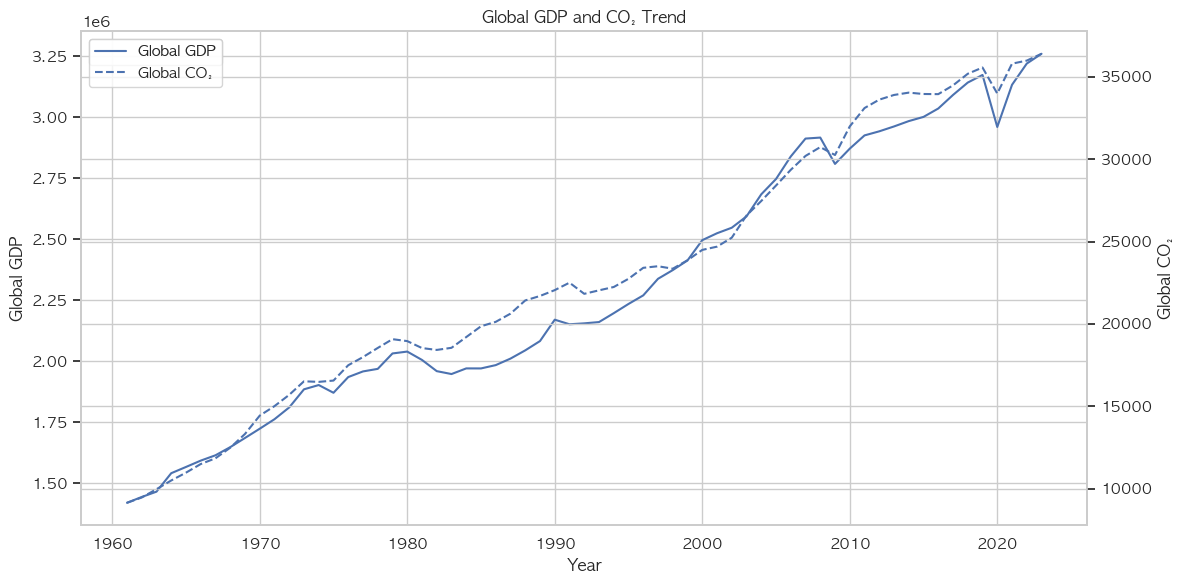

In [4]:
global_trend = (
    df_ts_valid.groupby("Year", as_index=False)[["GDP USD", "CO2"]]
    .sum()
    .sort_values("Year")
)

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(data=global_trend, x="Year", y="GDP USD", ax=ax1, label="Global GDP")
ax1.set_ylabel("Global GDP")

ax2 = ax1.twinx()
sns.lineplot(data=global_trend, x="Year", y="CO2", ax=ax2, label="Global CO₂", linestyle="--")
ax2.set_ylabel("Global CO₂")

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="upper left")

plt.title("Global GDP and CO₂ Trend")
plt.tight_layout()
plt.show()

**해석**  
전 세계 총량 기준으로 GDP와 CO₂는 장기적으로 함께 증가하는 경향을 보인다.  
이는 국가별 차이가 존재하더라도, 전체적으로는 여전히 성장과 배출이 강하게 연결되어 있음을 시사.

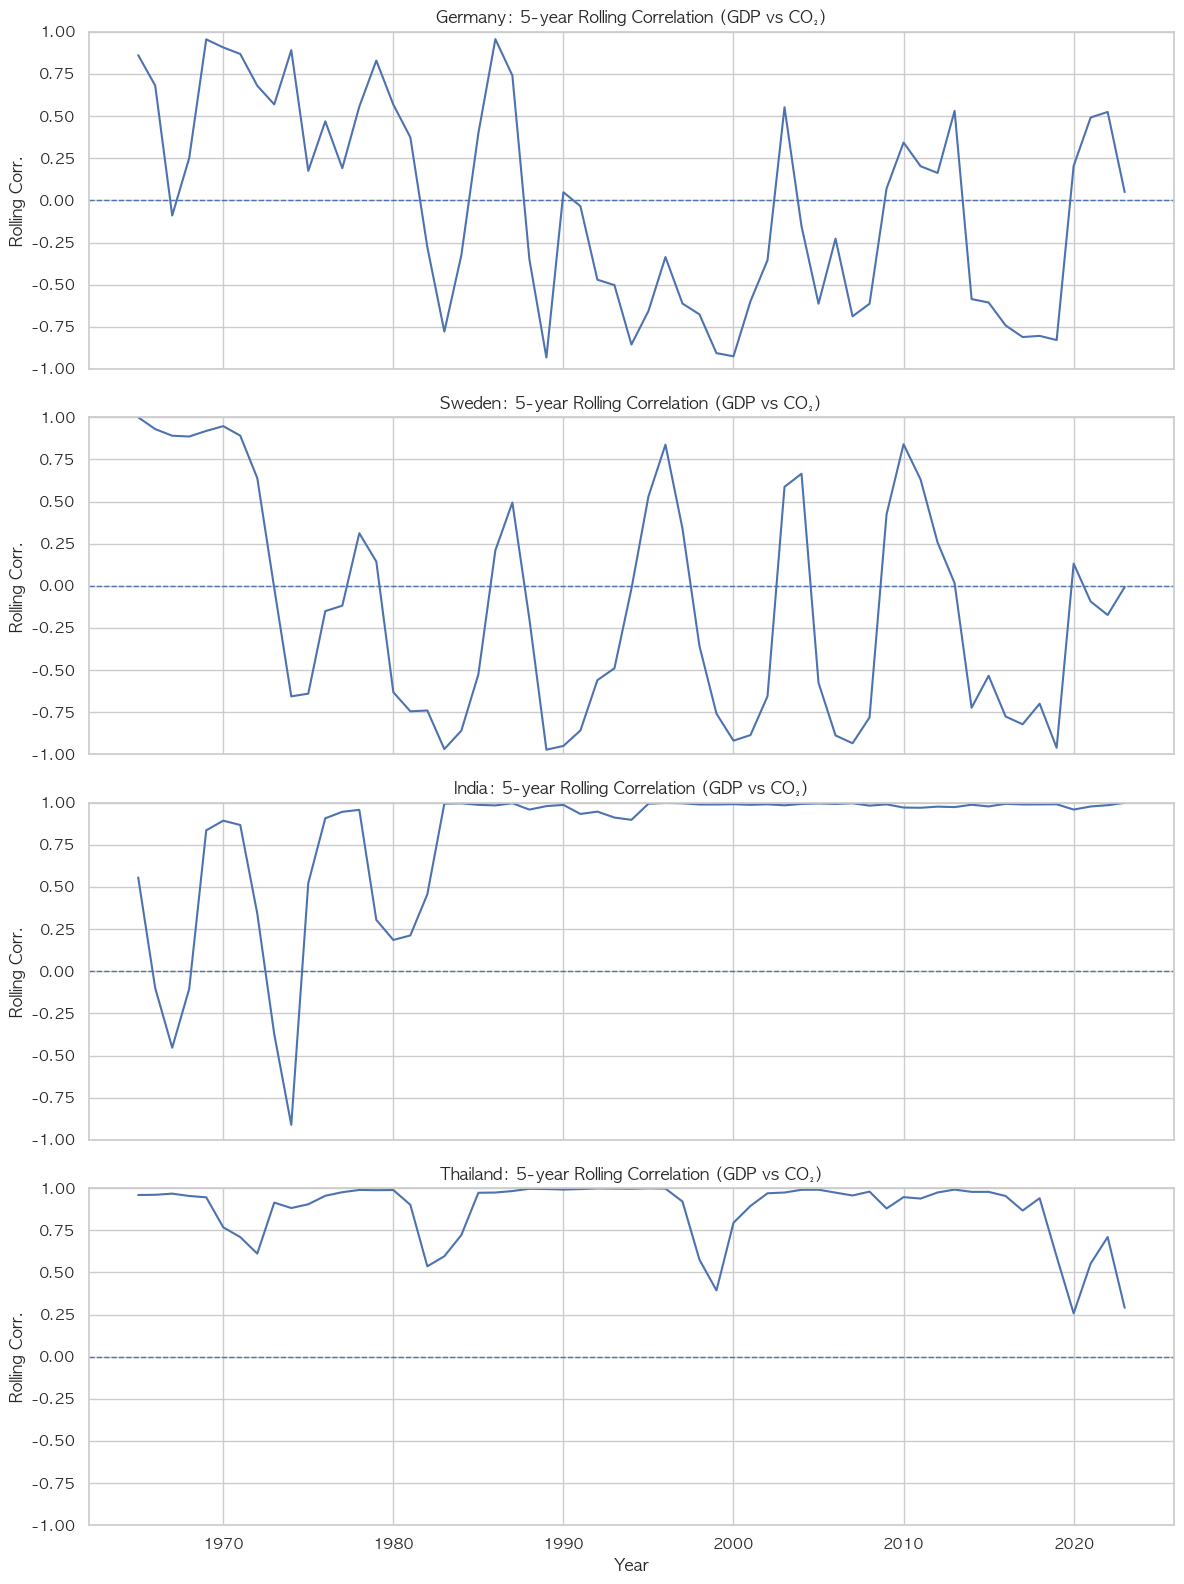

In [5]:
def rolling_corr_by_country(df, country, x_col="GDP USD Log", y_col="CO2 Log", window=5):
    tmp = (
        df[df["Country Name"] == country]
        .sort_values("Year")
        [["Year", x_col, y_col]]
        .dropna()
        .copy()
    )
    tmp["rolling_corr"] = tmp[x_col].rolling(window).corr(tmp[y_col])
    return tmp

countries_to_check = ["Germany", "Sweden", "India", "Thailand"]

fig, axes = plt.subplots(len(countries_to_check), 1, figsize=(12, 4 * len(countries_to_check)), sharex=True)

for ax, country in zip(axes, countries_to_check):
    tmp = rolling_corr_by_country(df_ts_valid, country, window=5)
    sns.lineplot(data=tmp, x="Year", y="rolling_corr", ax=ax)
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_ylim(-1, 1)
    ax.set_title(f"{country}: 5-year Rolling Correlation (GDP vs CO₂)")
    ax.set_ylabel("Rolling Corr.")

plt.xlabel("Year")
plt.tight_layout()
plt.show()

**해석**  
Rolling correlation은 전체 기간의 단일 상관계수보다 더 세밀하게,  
GDP와 CO₂의 관계가 시기별로 어떻게 변화했는지를 보여준다.  
특히 탈동조화 국가는 시간이 지날수록 상관계수가 낮아지거나 음의 방향으로 이동하는 경향을 보일 수 있다.

In [6]:
def period_corr(df, country, start_year, end_year, x_col="GDP USD Log", y_col="CO2 Log"):
    tmp = df[
        (df["Country Name"] == country) &
        (df["Year"] >= start_year) &
        (df["Year"] <= end_year)
    ][[x_col, y_col]].dropna()

    if len(tmp) < 3:
        return np.nan
    return tmp[x_col].corr(tmp[y_col])

countries_compare = ["Germany", "Sweden", "India", "Thailand"]

rows = []
for country in countries_compare:
    corr_2000_2010 = period_corr(df_ts_valid, country, 2000, 2010)
    corr_2011_2020 = period_corr(df_ts_valid, country, 2011, 2020)

    rows.append({
        "Country": country,
        "Corr_2000_2010": corr_2000_2010,
        "Corr_2011_2020": corr_2011_2020,
        "Change": corr_2011_2020 - corr_2000_2010 if pd.notna(corr_2000_2010) and pd.notna(corr_2011_2020) else np.nan
    })

period_corr_df = pd.DataFrame(rows)
period_corr_df

,Country,Corr_2000_2010,Corr_2011_2020,Change
0,Germany,-0.606874,-0.516273,0.090602
1,Sweden,-0.529849,-0.695160,-0.165311
2,India,0.991013,0.988383,-0.002630
3,Thailand,0.991630,0.876217,-0.115413


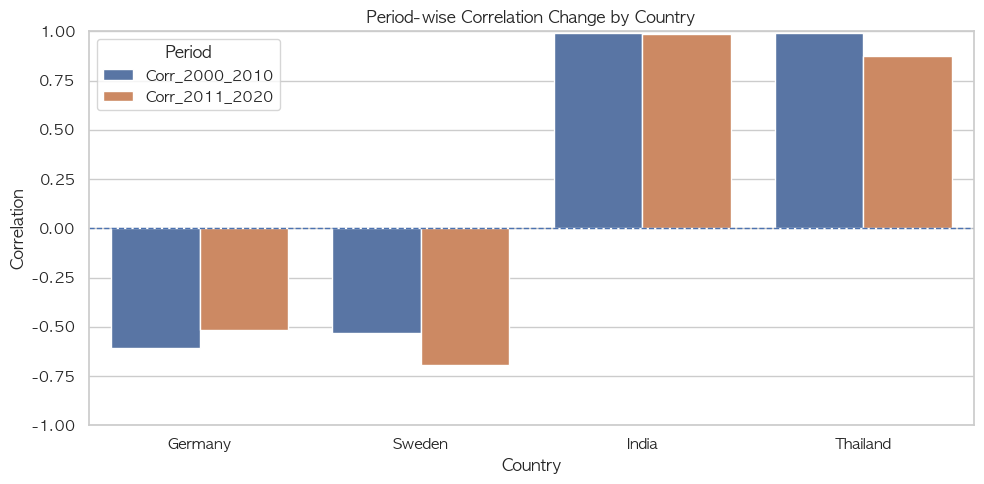

In [7]:
period_corr_long = period_corr_df.melt(
    id_vars="Country",
    value_vars=["Corr_2000_2010", "Corr_2011_2020"],
    var_name="Period",
    value_name="Correlation"
)

plt.figure(figsize=(10, 5))
sns.barplot(data=period_corr_long, x="Country", y="Correlation", hue="Period")
plt.axhline(0, linestyle="--", linewidth=1)
plt.ylim(-1, 1)
plt.title("Period-wise Correlation Change by Country")
plt.tight_layout()
plt.show()

**해석**  
기간을 나누어 상관관계를 비교하면, 동일한 국가에서도 성장–배출 관계가 시간에 따라 변화했는지 확인할 수 있다.  
후기 구간에서 상관관계가 낮아지거나 음의 방향으로 이동한 국가는 탈동조화가 강화되었을 가능성이 있다.

In [8]:
df_decouple = df_ts_valid[["Country Name", "Year", "GDP %", "CO2 %", "GDP Category", "Pop Category"]].copy()
df_decouple = df_decouple.replace([np.inf, -np.inf], np.nan)
df_decouple = df_decouple.dropna(subset=["GDP %", "CO2 %"]).copy()

# GDP 성장률이 0에 너무 가까우면 불안정해질 수 있어 제거
df_decouple = df_decouple[np.abs(df_decouple["GDP %"]) > 1e-6].copy()

df_decouple["Decoupling_Index"] = df_decouple["CO2 %"] / df_decouple["GDP %"]

print(df_decouple.shape)
df_decouple.head()

(12237, 7)


,Country Name,Year,GDP %,CO2 %,GDP Category,Pop Category,Decoupling_Index
1,Afghanistan,1962,-10.119484,40.325866,Low GDP,1M-10M,-3.984972
2,Afghanistan,1963,-10.119484,2.612482,Low GDP,1M-10M,-0.258164
3,Afghanistan,1964,-10.119484,18.670438,Low GDP,1M-10M,-1.844999
4,Afghanistan,1965,-10.119484,20.023838,Low GDP,10M-100M,-1.978741
5,Afghanistan,1966,-10.119484,8.341609,Low GDP,10M-100M,-0.824312


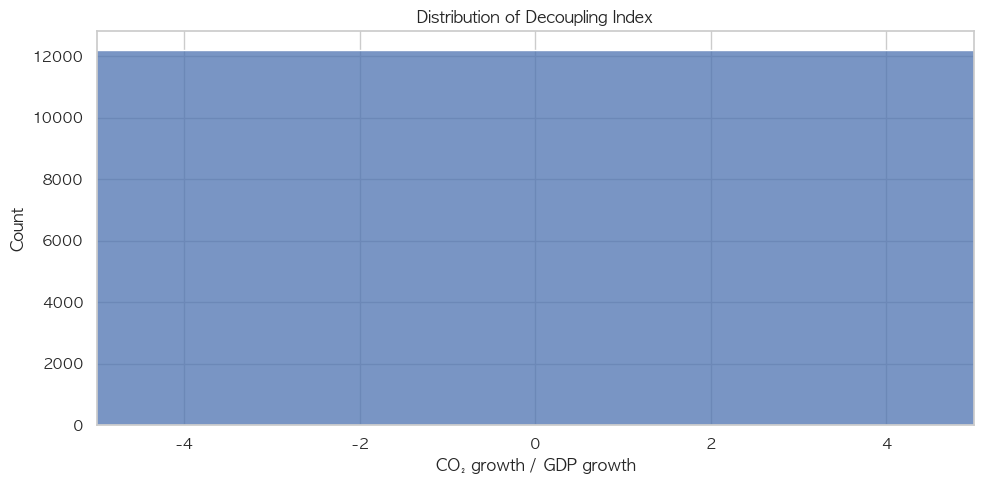

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df_decouple["Decoupling_Index"], bins=50)
plt.xlim(-5, 5)
plt.title("Distribution of Decoupling Index")
plt.xlabel("CO₂ growth / GDP growth")
plt.tight_layout()
plt.show()

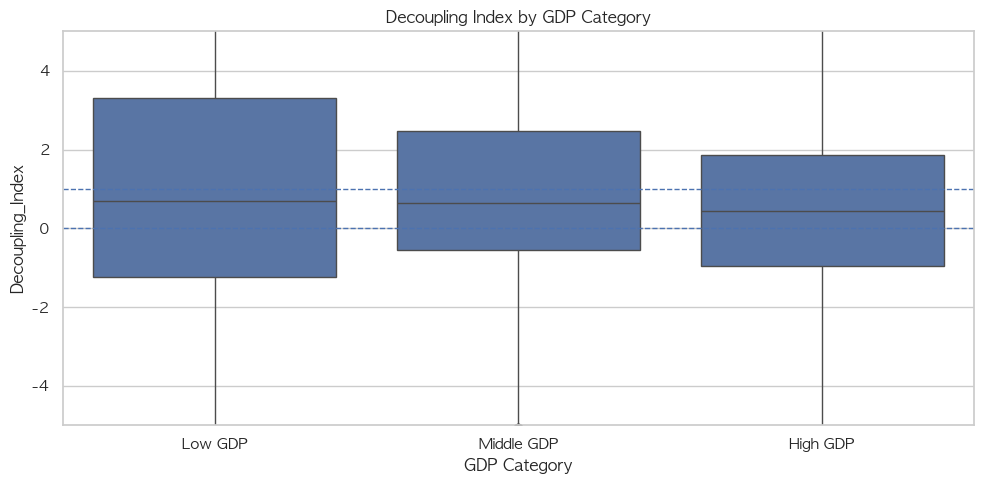

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_decouple, x="GDP Category", y="Decoupling_Index")
plt.axhline(0, linestyle="--", linewidth=1)
plt.axhline(1, linestyle="--", linewidth=1)
plt.ylim(-5, 5)
plt.title("Decoupling Index by GDP Category")
plt.tight_layout()
plt.show()

**해석**  
Decoupling Index는 GDP 성장에 비해 CO₂ 배출이 얼마나 빠르게 증가하거나 감소하는지를 보여준다.  
일반적으로 0보다 작으면 강한 탈동조화, 0과 1 사이면 약한 탈동조화 또는 완만한 동조화, 1보다 크면 동조화가 강한 상태로 해석할 수 있다.

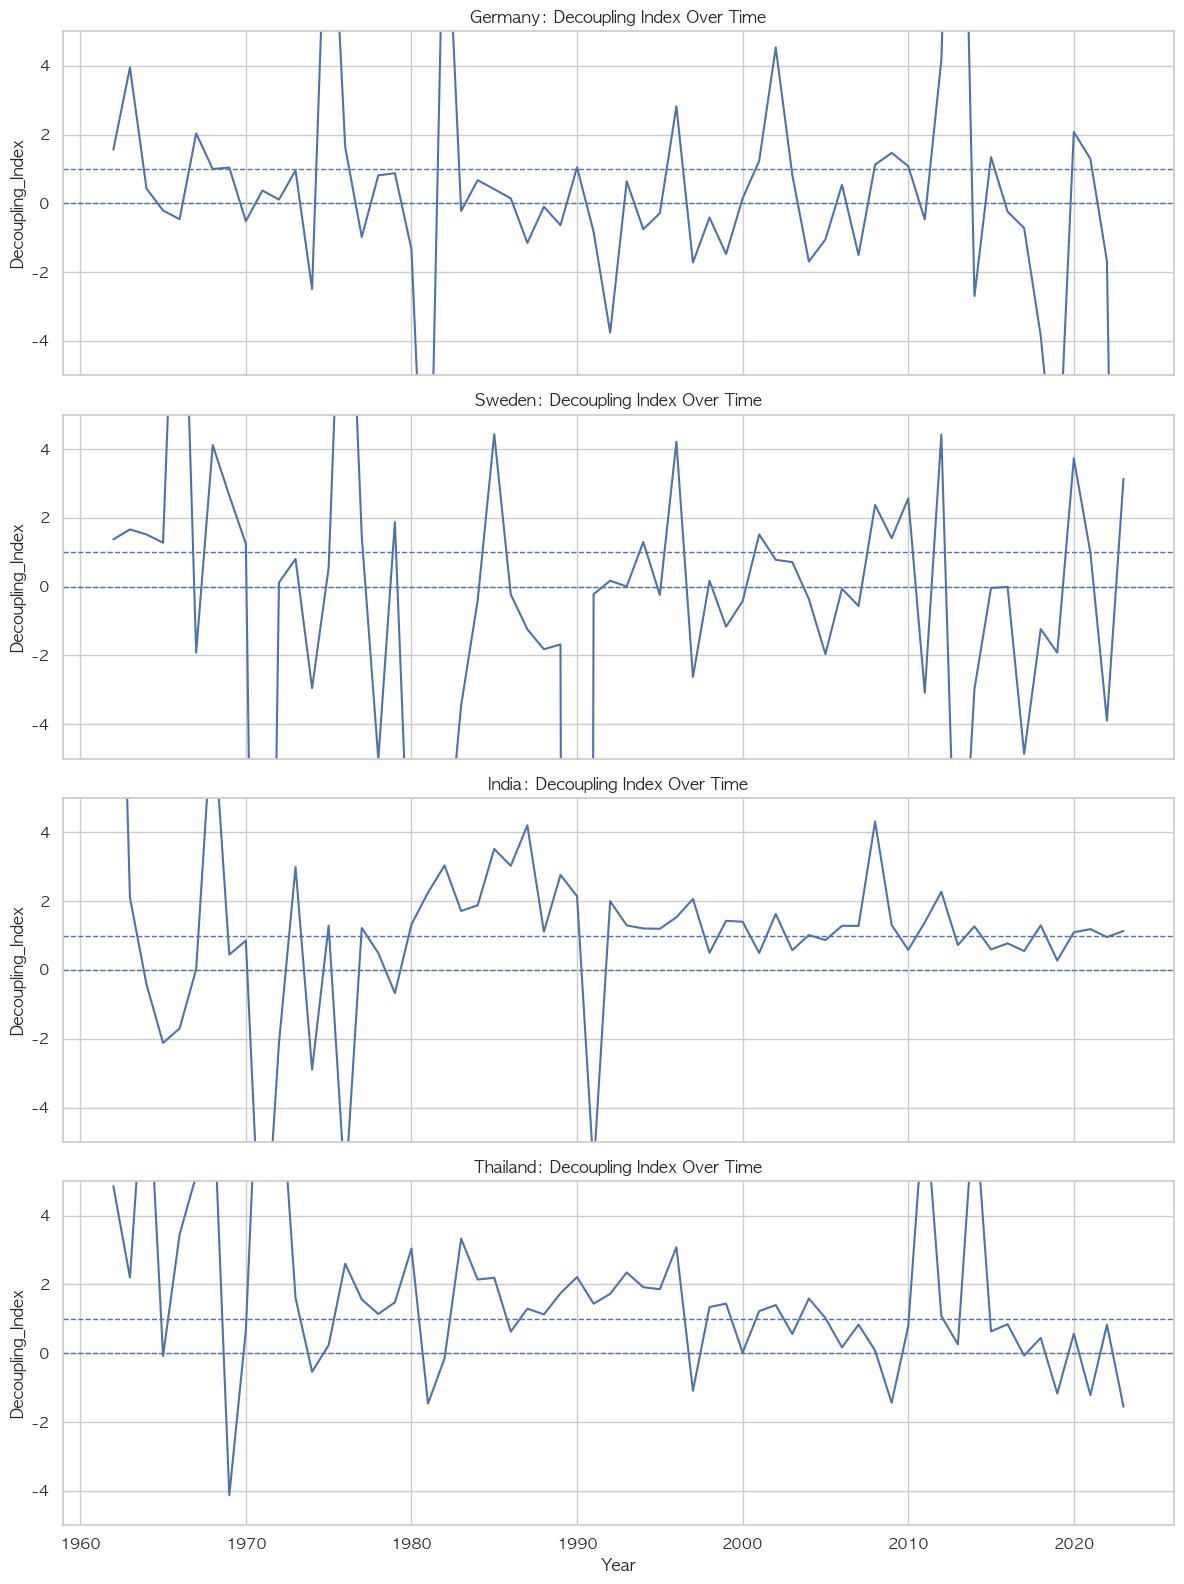

In [11]:
countries_to_check = ["Germany", "Sweden", "India", "Thailand"]

fig, axes = plt.subplots(len(countries_to_check), 1, figsize=(12, 4 * len(countries_to_check)), sharex=True)

for ax, country in zip(axes, countries_to_check):
    tmp = df_decouple[df_decouple["Country Name"] == country].sort_values("Year")
    sns.lineplot(data=tmp, x="Year", y="Decoupling_Index", ax=ax)
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.axhline(1, linestyle="--", linewidth=1)
    ax.set_ylim(-5, 5)
    ax.set_title(f"{country}: Decoupling Index Over Time")

plt.xlabel("Year")
plt.tight_layout()
plt.show()

## Conclusion

2차 분석에서는 1차 시각화 기반 탐색 분석을 확장하여,
GDP와 CO₂의 관계가 시간에 따라 어떻게 변화하는지를 추가적으로 살펴보았다.

분석 결과, 전체 기간을 하나의 상관계수로 요약하는 것만으로는 국가별 변화 양상을 충분히 설명하기 어렵고,
rolling correlation 및 기간 분할 분석을 통해 성장–배출 관계의 동태적 변화가 보다 분명하게 드러났다.

특히 일부 고소득 국가에서는 시간이 지날수록 GDP와 CO₂ 간의 상관관계가 약화되거나 음의 방향으로 이동하는 경향이 확인되었으며,
이는 탈동조화가 단일 시점의 현상이 아니라 장기적인 구조 변화의 결과일 수 있음을 시사한다.

또한 Decoupling Index 분석을 통해 국가별·시기별로 성장과 배출의 결합 강도가 다르게 나타남을 확인하였다.
이는 향후 정책 분석이나 계량적 모형 분석으로 확장할 수 있는 기초 자료가 된다.